<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/03_deep_learning/architectures/rnn_lstm_gru/experiment_lstm_time_series_forecasting_sine_wave_multistep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# LEVEL 1: BASIC TIME SERIES (LSTM)
# ============================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Create Simple Data (sine wave)
# -------------------------------
# This is like a repeating pattern (easy to learn)

time = np.arange(0, 100, 0.1)
data = np.sin(time)

# -------------------------------
# 2. Prepare Sequences
# -------------------------------
# Input = last 10 values
# Output = next value

seq_length = 10

X = []
y = []

for i in range(len(data) - seq_length):
    X.append(data[i:i+seq_length])
    y.append(data[i+seq_length])

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

# Add feature dimension
X = X.unsqueeze(-1)  # (samples, seq_len, 1)

# -------------------------------
# 3. LSTM Model
# -------------------------------
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()

        # LSTM layer
        self.lstm = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)

        # Output layer
        self.fc = nn.Linear(32, 1)

    def forward(self, x):

        # LSTM output
        out, _ = self.lstm(x)

        # Take last time step
        out = out[:, -1, :]

        # Final prediction
        return self.fc(out)


model = LSTMModel()

# -------------------------------
# 4. Training
# -------------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

loss_history_ts = []

for epoch in range(20):

    optimizer.zero_grad()

    preds = model(X)

    loss = loss_fn(preds.squeeze(), y)

    loss.backward()
    optimizer.step()

    loss_history_ts.append(loss.item())

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

/tmp/ipykernel_311/1173822126.py:33: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X = torch.tensor(X, dtype=torch.float32)


Epoch 1, Loss: 0.4986
Epoch 2, Loss: 0.4489
Epoch 3, Loss: 0.3978
Epoch 4, Loss: 0.3398
Epoch 5, Loss: 0.2729
Epoch 6, Loss: 0.1994
Epoch 7, Loss: 0.1386
Epoch 8, Loss: 0.1214
Epoch 9, Loss: 0.1340
Epoch 10, Loss: 0.1300
Epoch 11, Loss: 0.1056
Epoch 12, Loss: 0.0834
Epoch 13, Loss: 0.0697
Epoch 14, Loss: 0.0635
Epoch 15, Loss: 0.0644
Epoch 16, Loss: 0.0660
Epoch 17, Loss: 0.0603
Epoch 18, Loss: 0.0505
Epoch 19, Loss: 0.0424
Epoch 20, Loss: 0.0343


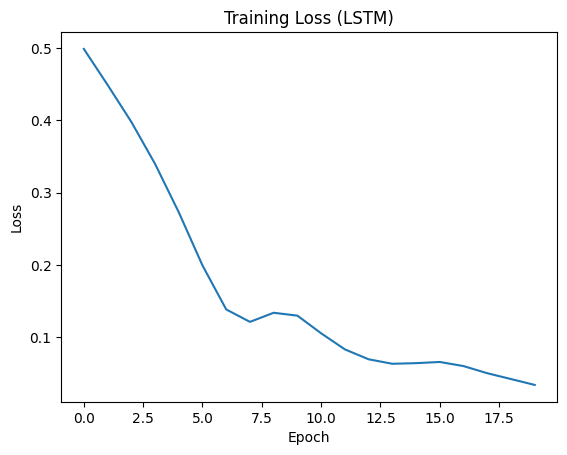

In [ ]:
plt.figure()
plt.plot(loss_history_ts)
plt.title("Training Loss (LSTM)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

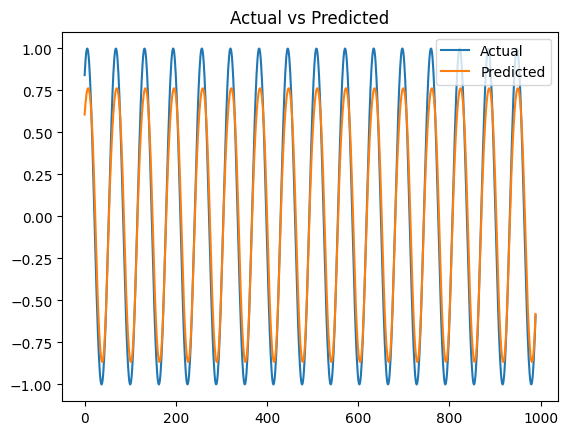

In [ ]:
# Get predictions
preds = model(X).detach().numpy()

plt.figure()

plt.plot(y.numpy(), label="Actual")
plt.plot(preds, label="Predicted")

plt.title("Actual vs Predicted")
plt.legend()
plt.show()

In [ ]:
# ============================================
# LEVEL 2: TRAIN / TEST SPLIT (REALISTIC)
# ============================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Data (same sine wave)
# -------------------------------
time = np.arange(0, 100, 0.1)
data = np.sin(time)

# -------------------------------
# 2. Create sequences
# -------------------------------
seq_length = 10

X = []
y = []

for i in range(len(data) - seq_length):
    X.append(data[i:i+seq_length])
    y.append(data[i+seq_length])

X = np.array(X)
y = np.array(y)

# -------------------------------
# 3. Train-Test Split
# -------------------------------
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
X_test  = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.float32)

# -------------------------------
# 4. Model (same)
# -------------------------------
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)


model = LSTMModel()

# -------------------------------
# 5. Training
# -------------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

train_loss = []
test_loss = []

for epoch in range(20):

    # Train
    model.train()
    optimizer.zero_grad()

    preds = model(X_train)
    loss = loss_fn(preds.squeeze(), y_train)

    loss.backward()
    optimizer.step()

    train_loss.append(loss.item())

    # Test (no learning here)
    model.eval()
    with torch.no_grad():
        test_preds = model(X_test)
        t_loss = loss_fn(test_preds.squeeze(), y_test)
        test_loss.append(t_loss.item())

    print(f"Epoch {epoch+1}, Train Loss: {loss.item():.4f}, Test Loss: {t_loss.item():.4f}")

Epoch 1, Train Loss: 0.4510, Test Loss: 0.3900
Epoch 2, Train Loss: 0.3798, Test Loss: 0.3089
Epoch 3, Train Loss: 0.3054, Test Loss: 0.2224
Epoch 4, Train Loss: 0.2236, Test Loss: 0.1355
Epoch 5, Train Loss: 0.1386, Test Loss: 0.1022
Epoch 6, Train Loss: 0.1059, Test Loss: 0.1520
Epoch 7, Train Loss: 0.1584, Test Loss: 0.1279
Epoch 8, Train Loss: 0.1333, Test Loss: 0.0858
Epoch 9, Train Loss: 0.0900, Test Loss: 0.0696
Epoch 10, Train Loss: 0.0732, Test Loss: 0.0726
Epoch 11, Train Loss: 0.0759, Test Loss: 0.0783
Epoch 12, Train Loss: 0.0817, Test Loss: 0.0794
Epoch 13, Train Loss: 0.0830, Test Loss: 0.0743
Epoch 14, Train Loss: 0.0780, Test Loss: 0.0641
Epoch 15, Train Loss: 0.0673, Test Loss: 0.0507
Epoch 16, Train Loss: 0.0534, Test Loss: 0.0377
Epoch 17, Train Loss: 0.0398, Test Loss: 0.0286
Epoch 18, Train Loss: 0.0304, Test Loss: 0.0248
Epoch 19, Train Loss: 0.0265, Test Loss: 0.0244
Epoch 20, Train Loss: 0.0261, Test Loss: 0.0237


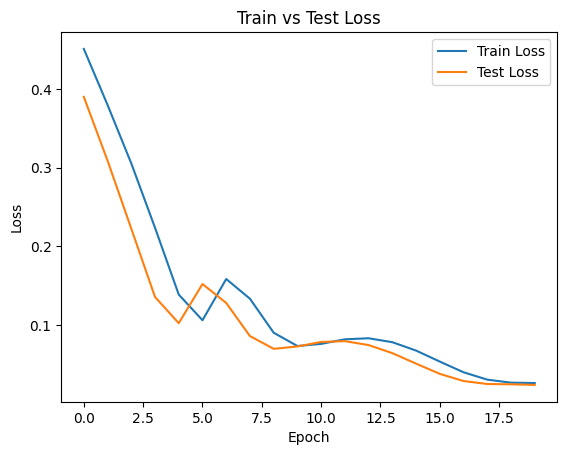

In [ ]:
plt.figure()

plt.plot(train_loss, label="Train Loss")
plt.plot(test_loss, label="Test Loss")

plt.title("Train vs Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

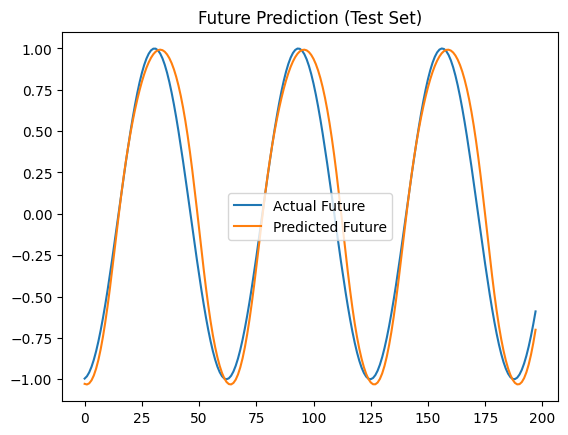

In [ ]:
# Predictions on test data
preds = model(X_test).detach().numpy()

plt.figure()

plt.plot(y_test.numpy(), label="Actual Future")
plt.plot(preds, label="Predicted Future")

plt.title("Future Prediction (Test Set)")
plt.legend()
plt.show()

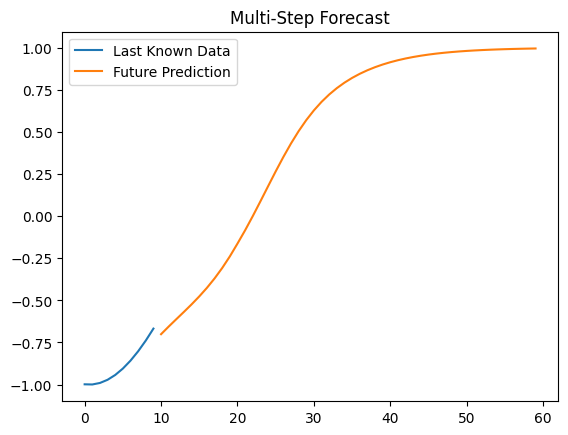

In [ ]:
# ============================================
# LEVEL 3: MULTI-STEP FORECASTING
# ============================================

import torch
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Use trained model from Level 2
# -------------------------------
# We assume model, X_test, y_test exist

# -------------------------------
# 2. Multi-step prediction function
# -------------------------------
def predict_future(model, start_sequence, steps=50):
    """
    start_sequence: last known values
    steps: how many future points to predict
    """

    model.eval()

    seq = start_sequence.clone()
    predictions = []

    for _ in range(steps):

        # Predict next value
        with torch.no_grad():
            pred = model(seq.unsqueeze(0)).item()

        predictions.append(pred)

        # 🔥 Update sequence (rolling window)
        seq = torch.roll(seq, -1)
        seq[-1] = pred

    return predictions


# -------------------------------
# 3. Take last test sequence
# -------------------------------
start_seq = X_test[-1] # Removed .squeeze() to keep the feature dimension

future_preds = predict_future(model, start_seq, steps=50)

# -------------------------------
# 4. Plot results
# -------------------------------
plt.figure()

# Past data
plt.plot(range(len(start_seq)), start_seq.numpy(), label="Last Known Data")

# Future prediction
plt.plot(range(len(start_seq), len(start_seq)+50), future_preds, label="Future Prediction")

plt.title("Multi-Step Forecast")
plt.legend()
plt.show()

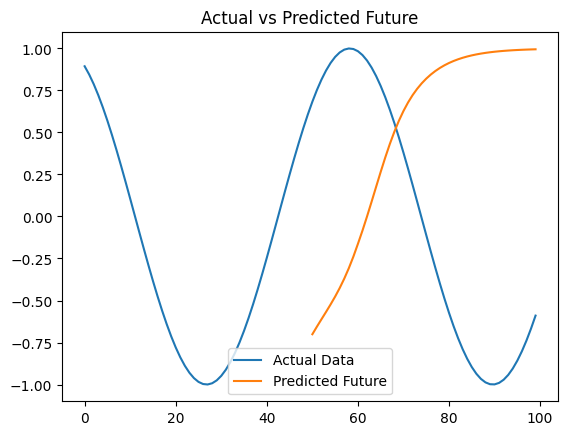

In [ ]:
full_data = data[-100:]  # last part of original data

plt.figure()

plt.plot(full_data, label="Actual Data")

# Overlay predictions
start = len(full_data) - 50
plt.plot(range(start, start+50), future_preds, label="Predicted Future")

plt.title("Actual vs Predicted Future")
plt.legend()
plt.show()

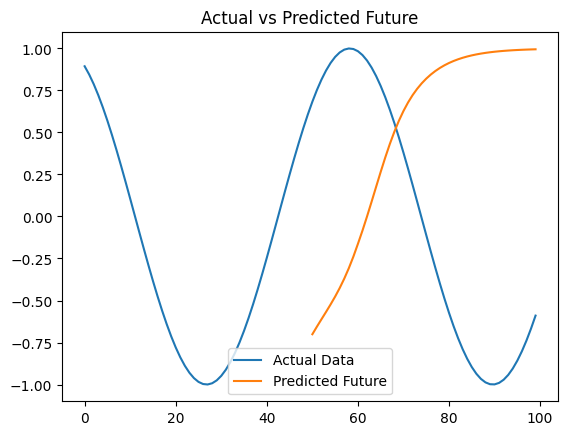

In [ ]:
full_data = data[-100:]  # last part of original data

plt.figure()

plt.plot(full_data, label="Actual Data")

# Overlay predictions
start = len(full_data) - 50
plt.plot(range(start, start+50), future_preds, label="Predicted Future")

plt.title("Actual vs Predicted Future")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

model.eval()

with torch.no_grad():
    preds = model(X_test).squeeze().numpy()

# RMSE
rmse = np.sqrt(mean_squared_error(y_test.numpy(), preds))

# MAE
mae = mean_absolute_error(y_test.numpy(), preds)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.15381682843159747
MAE: 0.11222432553768158


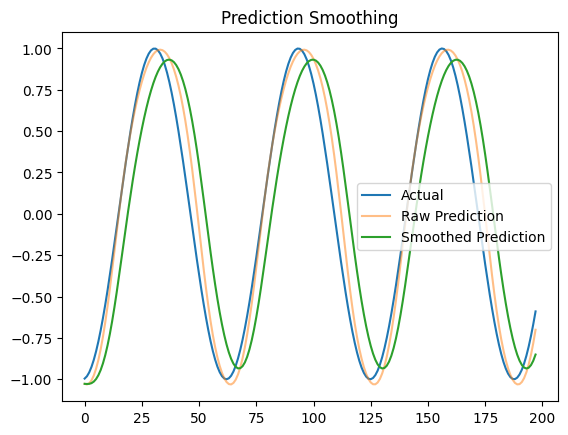

In [ ]:
def smooth(data, factor=0.8):
    smoothed = []
    for d in data:
        if smoothed:
            smoothed.append(smoothed[-1]*factor + d*(1-factor))
        else:
            smoothed.append(d)
    return smoothed

smooth_preds = smooth(preds)

plt.figure()

plt.plot(y_test.numpy(), label="Actual")
plt.plot(preds, alpha=0.5, label="Raw Prediction")
plt.plot(smooth_preds, label="Smoothed Prediction")

plt.title("Prediction Smoothing")
plt.legend()
plt.show()

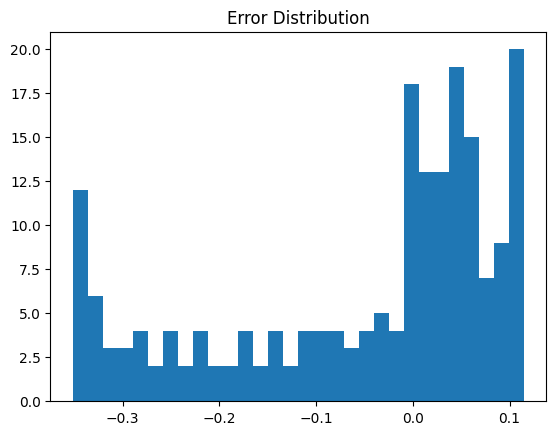

In [ ]:
errors = y_test.numpy() - preds

plt.figure()
plt.hist(errors, bins=30)
plt.title("Error Distribution")
plt.show()